In [1]:
import strawberryfields as sf
from strawberryfields.ops import *
import numpy as np
from scipy.special import erfc
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from helper_functions import protocols

In [49]:
from importlib import reload
reload(protocols)

<module 'helper_functions.protocols' from '/workspaces/Quantum-Communications-Internship-IRIDA-/helper_functions/protocols.py'>

In [ ]:
alpha_grid = np.arange(0, 1, 0.01)
N_cs, p_err = protocols.perr_cs(alpha_grid=alpha_grid, homodyne_angle=0, num_samples=1000)

Progress: 100/100

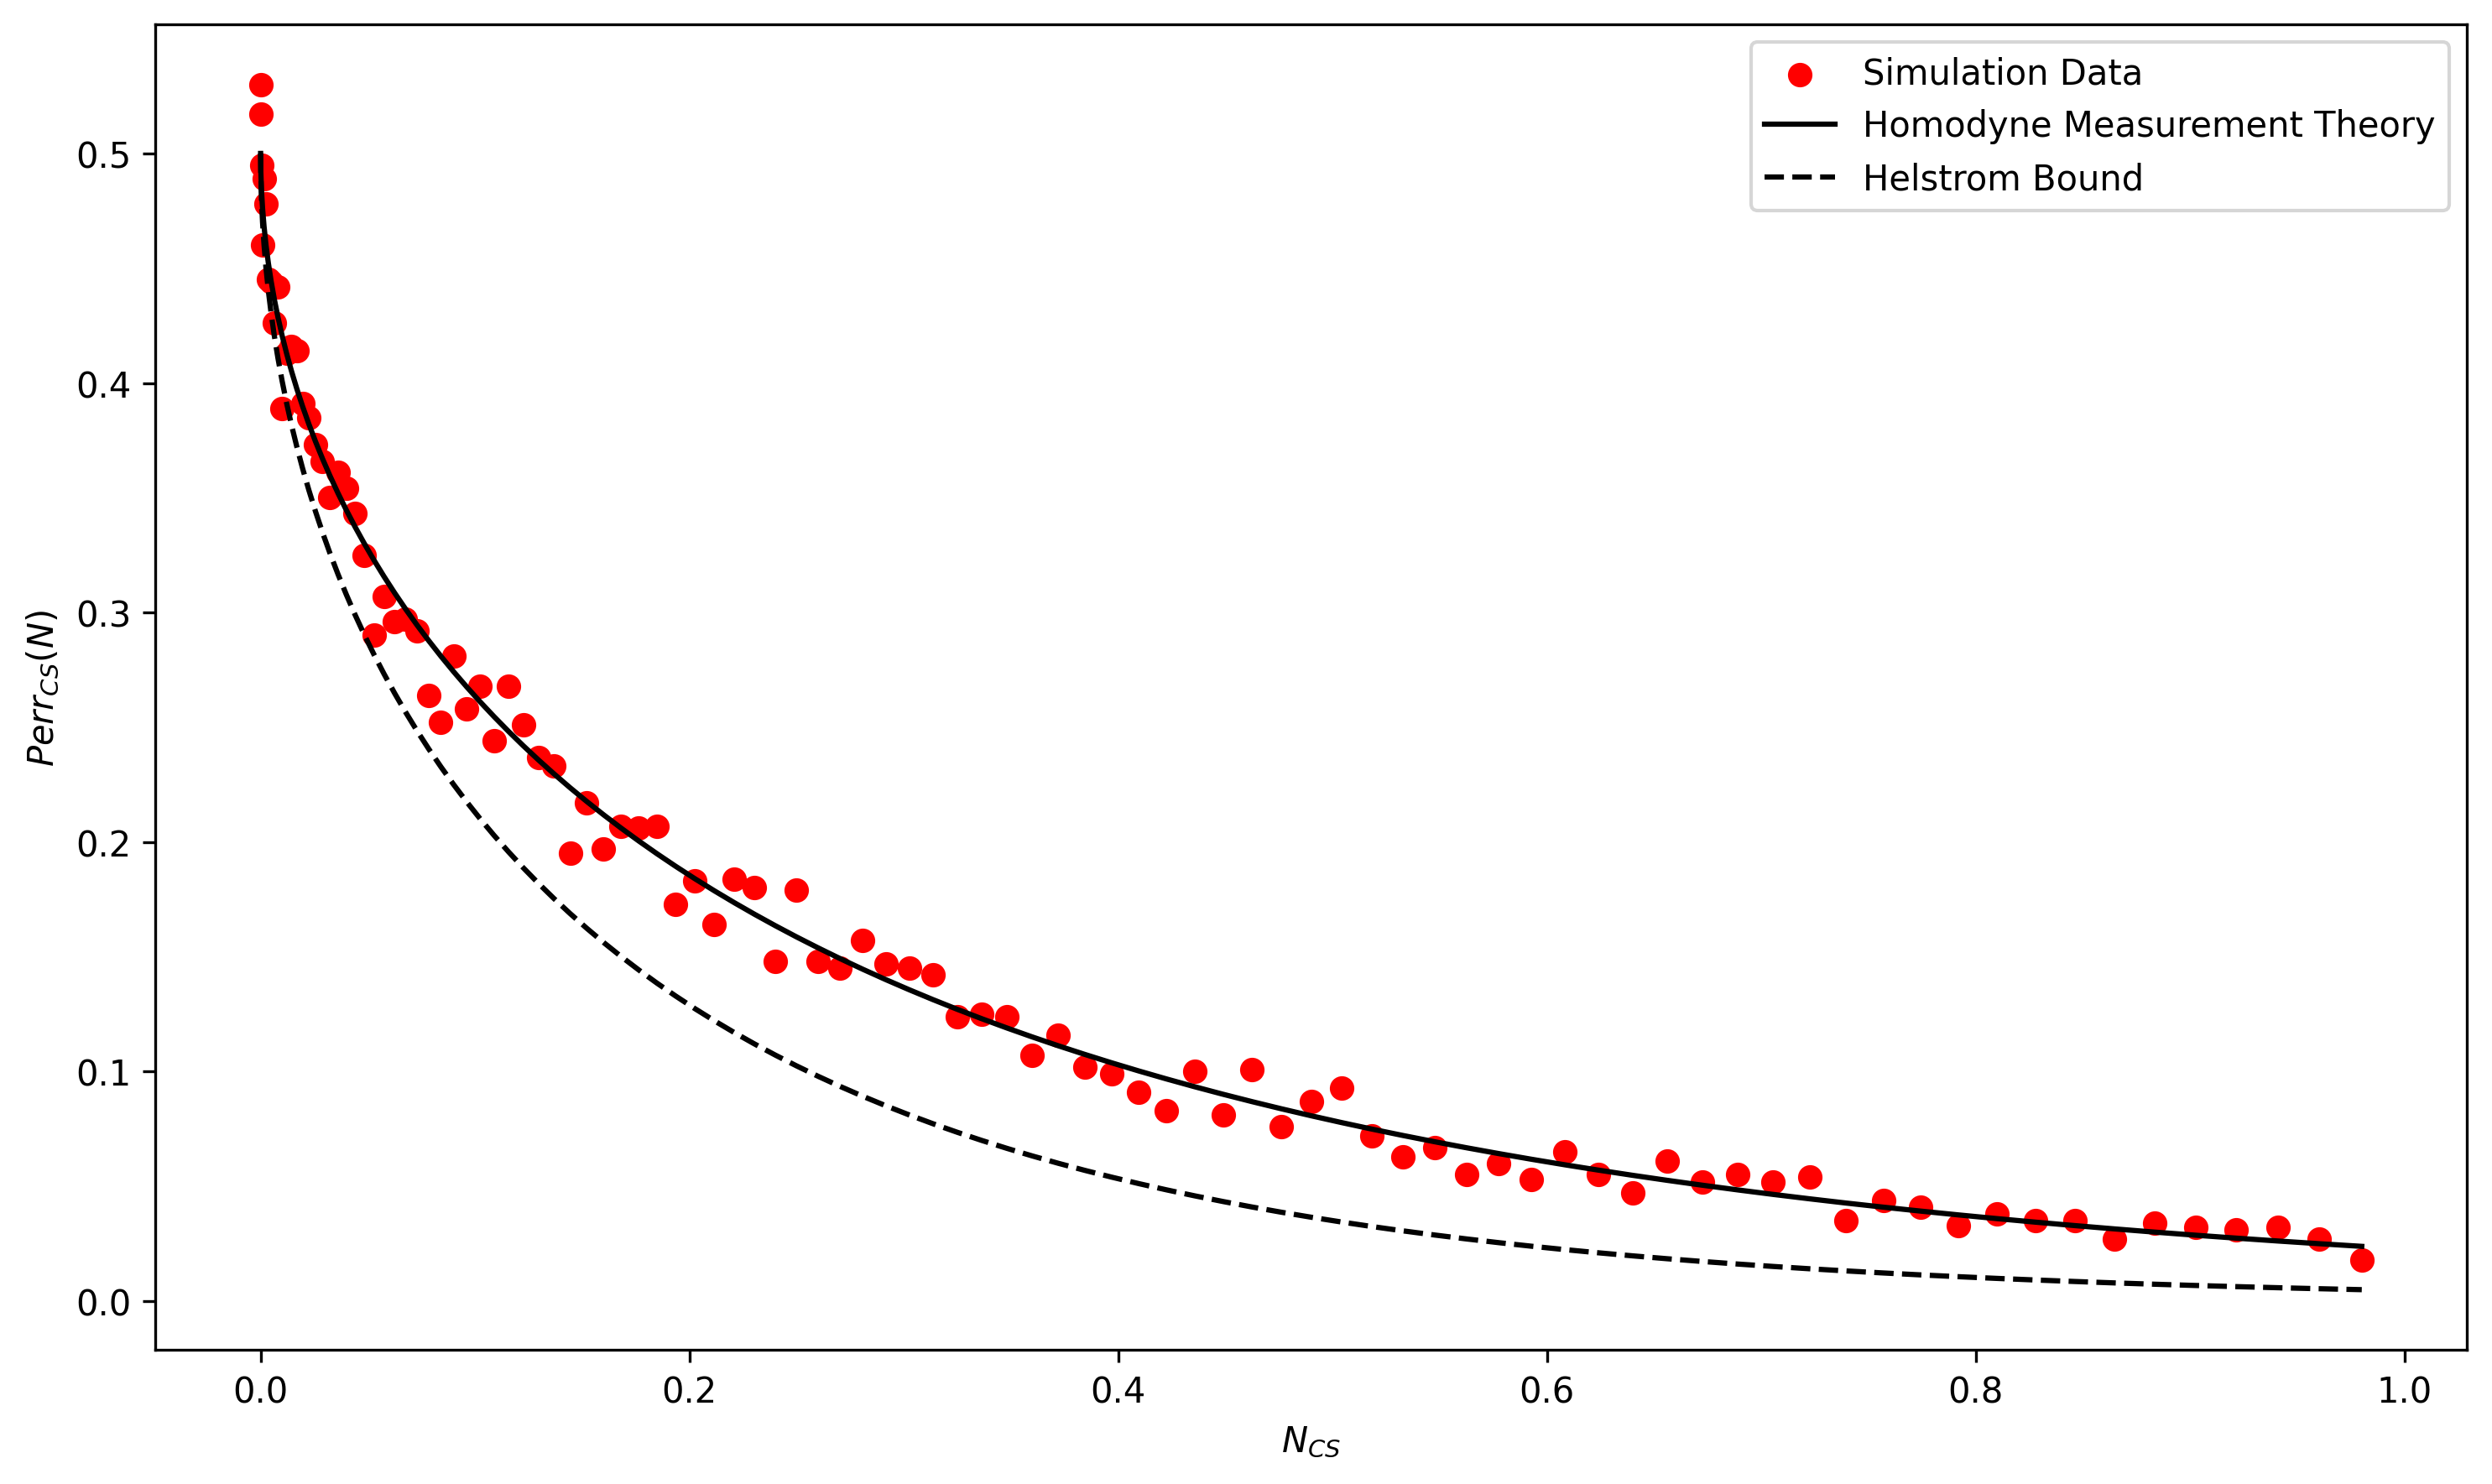

In [ ]:
plt.figure(figsize=(10, 6), dpi=300)
plt.ylabel(r"$Perr_{CS}(N)$")
plt.xlabel(r"$N_{CS}$")

plt.scatter(N_cs, p_err, label="Simulation Data", color="red")
plt.plot(N_cs, 0.5 * erfc(np.sqrt(2*N_cs)), label="Homodyne Measurement Theory", color="black")
plt.plot(N_cs, 0.5 * (1 - np.sqrt(1 - np.exp(-4*N_cs))), label="Helstrom Bound", color="black", linestyle="--")

plt.tight_layout()
plt.legend()
plt.show()

In [2]:
N_grid = np.arange(0, 1, 0.02)
beta_grid = np.arange(0, 1, 0.02)
p_err = protocols.perr_dss(N_grid=N_grid, beta_grid=beta_grid, homodyne_angle=0, num_samples=500)

Progress: 50/50

In [3]:
np.savez("perr_data_dss_N50_b50_S500.npz", N_grid=N_grid, beta_grid=beta_grid, p_err=p_err)

In [24]:
data = np.load("perr_data_dss_N50_b50_S500.npz")

N_grid = data["N_grid"]
beta_grid = data["beta_grid"]
p_err = data["p_err"]

In [50]:
N_mesh, beta_mesh = np.meshgrid(N_grid, beta_grid, indexing='ij')
p_err_theory = protocols.P_err_theory(N_mesh, beta_mesh)
z_theory = np.log(p_err_theory)
zmin = np.floor(np.min(z_theory))
zmax = np.ceil(np.max(z_theory))
ticks = np.arange(zmin, zmax + 1)
fig = go.Figure()
fig.add_trace(go.Surface(x=N_mesh, y=beta_mesh, z=np.log(p_err), colorscale="Greys", colorbar=dict(title="P_err")))
fig.add_trace(go.Surface(x=N_mesh, y=beta_mesh, z=np.log(p_err_theory), colorscale="Plasma", colorbar=dict(title="log(P_err)")))
fig.update_layout(title="Error probability", scene=dict(xaxis_title="N", yaxis_title="β",  zaxis=dict(title="log(P_err)", tickmode="array", 
            tickvals=ticks, ticktext=[rf"10e{int(t)}" for t in ticks])), width=700, height=700)

fig.show()

/tmp/ipykernel_3470/1164301985.py:8: RuntimeWarning: divide by zero encountered in log


In [20]:
def helstrom_bound_dss(N, beta):

    exponent = -4 * N * (1 - beta) * (
        1
        + 2 * N * beta
        + 2 * np.sqrt(N * beta * (1 + N * beta))
        )

    return 0.5 * (1 - np.sqrt(1 - np.exp(exponent)))

N_grid_helstrom = N_grid
beta_grid_helstrom = beta_grid

N_mesh, beta_mesh = np.meshgrid(N_grid_helstrom, beta_grid_helstrom, indexing='ij')
p_err_helstrom = helstrom_bound_dss(N_mesh, beta_mesh)
fig = go.Figure(data=[go.Surface(x=N_mesh, y=beta_mesh, z=p_err_helstrom, colorscale="Plasma", colorbar=dict(title="P_err"))])
fig.update_layout(title="Error probability", scene=dict(xaxis_title="N", yaxis_title="β", zaxis_title="P_err"), width=700, height=700)
fig.show()